
#**Diplomatura en Ciencia de Datos, Aprendizaje Automático y sus Aplicaciones**

##**Edición 2025**

---

# Trabajo práctico entregable - Parte 2

In [1]:
import io
import matplotlib
import matplotlib.pyplot as plt
import numpy
import pandas as pd
import seaborn as sns

#seaborn.set_context('talk')

## Lectura del dataset

En la notebook 00 se explican los detalles de la siguiente sección.

In [2]:
url = 'https://raw.githubusercontent.com/DiploDatos/AnalisisyVisualizacion/refs/heads/master/sysarmy_survey_2025_processed.csv'
df = pd.read_csv(url)

In [3]:
df[:3]

,Unnamed: 0,work_province,work_dedication,work_contract_type,salary_monthly_BRUTO,salary_monthly_NETO,salary_in_usd,salary_last_dollar_value,salary_has_bonus,salary_bonus_tied_to,...,salir_o_seguir_contestando_sobre_las_guardias,work_on_call_duty,salary_on_call_duty_charge,aclara_el_numero_que_ingresaste_en_el_campo_anterior,profile_age,profile_gender,habias_respondido_nuestra_encuesta_en_ediciones_anteriores,sueldo_dolarizado,seniority,_sal
0,0,Ciudad Autónoma de Buenos Aires,Part-Time,Staff (planta permanente),6500000.0,5800000.0,Cobro parte del salario en dólares,NaN,De uno a tres sueldos,Performance de la compañía,...,NaN,NaN,NaN,NaN,45,Hombre Cis,Sí,True,Senior,6500000.0
1,1,Ciudad Autónoma de Buenos Aires,Full-Time,Contractor,12700000.0,10200000.0,Cobro todo el salario en dólares,NaN,Un sueldo,Performance de la compañía,...,Terminar encuesta,No,0.0,Bruto,32,Mujer Cis,Sí,True,Senior,12700000.0
2,2,Córdoba,Full-Time,Staff (planta permanente),3952805.0,3137662.0,Cobro parte del salario en dólares,985,No,No recibo bono,...,NaN,NaN,NaN,NaN,29,Hombre Cis,Sí,True,Semi-Senior,3952805.0


In [4]:
df.profile_gender.unique()

array(['Hombre Cis', 'Mujer Cis', 'No binarie', 'Prefiero no decir', nan,
       'Trans', 'Queer', 'Lesbiana', 'Agénero'], dtype=object)

In [5]:
df.loc[:,'profile_g'] = df.profile_gender.replace({'Hombre Cis': 'Varón cis','Mujer Cis': 'Mujer cis','Queer':'Diversidades','Trans':'Diversidades','Queer':'Diversidades','Lesbiana':'Diversidades','Agénero':'Diversidades'}).fillna(False)

In [6]:
alpha = 0.05

In [7]:
is_man = df.profile_g == 'Varón cis'
is_woman = df.profile_g == 'Mujer cis'


In [8]:
groupA = df[(15000000>df.salary_monthly_NETO)&(df.salary_monthly_NETO > 100000) & is_man].salary_monthly_NETO
groupB  = df[(df.salary_monthly_NETO > 100000) & is_woman].salary_monthly_NETO


In [9]:
print(f"Mean: {groupA.mean()}")
print(f"Median: {groupA.median()}")
print(f"Standard Deviation: {groupA.std()}")

Mean: 2403162.4648686917
Median: 2000000.0
Standard Deviation: 1606418.565282235


In [10]:
print(f"Mean: {groupB.mean()}")
print(f"Median: {groupB.median()}")
print(f"Standard Deviation: {groupB.std()}")

Mean: 1926464.3164589824
Median: 1660669.0
Standard Deviation: 1246694.955339217


Text(0.5, 0, 'Salary')

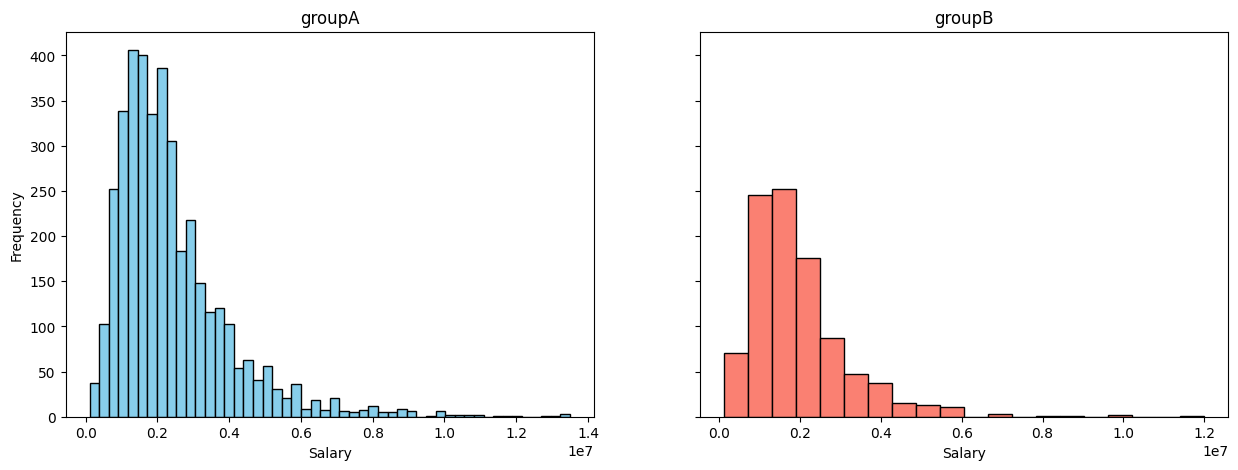

In [11]:


# Create the histograms
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)  # 1 row, 3 columns

# Plot each group on a separate subplot
axes[0].hist(groupA, bins=50, color='skyblue', edgecolor='black')
axes[0].set_title('groupA')
axes[0].set_xlabel('Salary')
axes[0].set_ylabel('Frequency')

axes[1].hist(groupB, bins=20, color='salmon', edgecolor='black')
axes[1].set_title('groupB')
axes[1].set_xlabel('Salary')





## Ejercicio 1: Estimación

**Consigna:**  Calcular una estimación puntual y un intervalo de confianza de nivel (1-alpha) para la resta entre la media del salario Neto para Hombres y la media del salario Neto para mujeres (diferencia de las medias entre el grupoA y grupoB).
¿Cómo se relaciona este intervalo de confianza con el test de hipótesis para diferencia de medias?

Estimación puntual (μA - μB): 476698.15
Intervalo de confianza 95.0%: (383082.86, 570313.44)
Error estándar: 47732.36
Grados de libertad (aprox. Welch): 1839.83

Relación con el test de hipótesis:
* Si el intervalo de confianza contiene el 0, no podemos rechazar H0: μA = μB
* Si el intervalo de confianza NO contiene el 0, rechazamos H0 en favor de H1: μA ≠ μB

Estadístico t: 9.9869
Valor p: 0.0000
Con α = 0.05, rechazamos H0: existe diferencia significativa entre las medias salariales


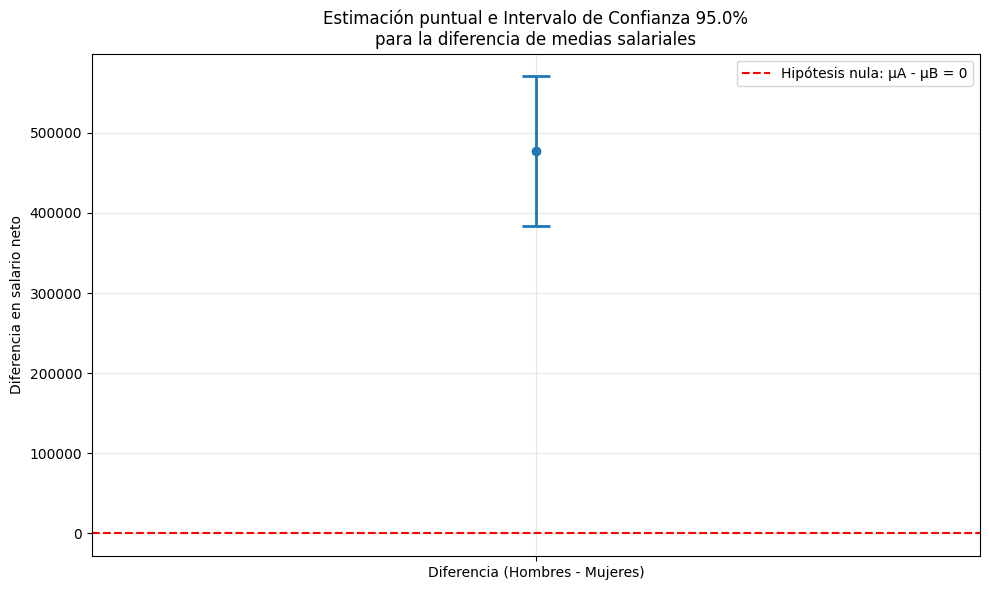

In [12]:
# Ejercicio 1: Estimación puntual e intervalo de confianza para diferencia de medias
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# Función para calcular estimación puntual e intervalo de confianza
def calcular_diferencia_medias(groupA, groupB, alpha=0.05):
    """
    Calcula la estimación puntual y el intervalo de confianza para la diferencia de medias

    Args:
        groupA: Serie con salarios del grupo A (hombres)
        groupB: Serie con salarios del grupo B (mujeres)
        alpha: Nivel de significancia (por defecto 0.05 para IC del 95%)

    Returns:
        Estimación puntual e intervalo de confianza
    """
    # Tamaños muestrales
    n_A = len(groupA)
    n_B = len(groupB)

    # Medias muestrales
    mean_A = np.mean(groupA)
    mean_B = np.mean(groupB)

    # Varianzas muestrales
    var_A = np.var(groupA, ddof=1)  # ddof=1 para varianza muestral insesgada
    var_B = np.var(groupB, ddof=1)

    # Estimación puntual: diferencia de medias
    diff_means = mean_A - mean_B

    # Error estándar de la diferencia de medias
    se_diff = np.sqrt(var_A/n_A + var_B/n_B)

    # Grados de libertad (aproximación de Welch-Satterthwaite)
    df = ((var_A/n_A + var_B/n_B)**2) / ((var_A/n_A)**2/(n_A-1) + (var_B/n_B)**2/(n_B-1))

    # Valor crítico para el intervalo de confianza
    t_critical = stats.t.ppf(1 - alpha/2, df)

    # Intervalo de confianza
    lower_bound = diff_means - t_critical * se_diff
    upper_bound = diff_means + t_critical * se_diff

    return diff_means, (lower_bound, upper_bound), se_diff, df

# Calcular y mostrar resultados
alpha = 0.05  # Para un IC del 95%
diff_means, confidence_interval, se_diff, df = calcular_diferencia_medias(groupA, groupB, alpha)

# Imprimir resultados
print(f"Estimación puntual (μA - μB): {diff_means:.2f}")
print(f"Intervalo de confianza {(1-alpha)*100}%: ({confidence_interval[0]:.2f}, {confidence_interval[1]:.2f})")
print(f"Error estándar: {se_diff:.2f}")
print(f"Grados de libertad (aprox. Welch): {df:.2f}")

# Relación con el test de hipótesis
print("\nRelación con el test de hipótesis:")
print("* Si el intervalo de confianza contiene el 0, no podemos rechazar H0: μA = μB")
print("* Si el intervalo de confianza NO contiene el 0, rechazamos H0 en favor de H1: μA ≠ μB")

# Test de hipótesis para verificar
t_stat = diff_means / se_diff
p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

print(f"\nEstadístico t: {t_stat:.4f}")
print(f"Valor p: {p_value:.4f}")

if p_value < alpha:
    print(f"Con α = {alpha}, rechazamos H0: existe diferencia significativa entre las medias salariales")
else:
    print(f"Con α = {alpha}, no rechazamos H0: no hay evidencia de diferencia significativa entre las medias salariales")

# Visualizar el intervalo de confianza
plt.figure(figsize=(10, 6))
plt.errorbar(x=['Diferencia (Hombres - Mujeres)'], y=[diff_means],
             yerr=[[diff_means - confidence_interval[0]], [confidence_interval[1] - diff_means]],
             fmt='o', capsize=10, capthick=2, elinewidth=2)
plt.axhline(y=0, color='r', linestyle='--', label='Hipótesis nula: μA - μB = 0')
plt.grid(True, alpha=0.3)
plt.ylabel('Diferencia en salario neto')
plt.title(f'Estimación puntual e Intervalo de Confianza {(1-alpha)*100}%\npara la diferencia de medias salariales')
plt.legend()
plt.tight_layout()
plt.show()

## Ejercicio 2: Test de hipótesis



### 2.1 Formalización

Describir formalmente los distintos componentes de un test de hipótesis para comprobar si la distribución de los salarios es distinta entre los grupos A y B.

**Hipótesis Nula**

$H_0=...$

**Estadístico (Pivote)**
  * Identificar el estadístico
  * Escribir qué distribución tiene bajo $H_0$


### 2.2 P-valor

1. Calcule el p-valor y decida si rechazar o no la hipótesis nula.
2. Interprete el resultado.

Links útiles:
* [Test de hipótesis usando scipy](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind.html)
* [Test de Welch](http://daniellakens.blogspot.com/2015/01/always-use-welchs-t-test-instead-of.html)

2.1 FORMALIZACIÓN DEL TEST DE HIPÓTESIS
---------------------------------------
Hipótesis Nula (H₀): μA - μB = 0 (No hay diferencia entre medias salariales)
Hipótesis Alternativa (H₁): μA - μB ≠ 0 (Existe diferencia entre medias salariales)

Estadístico (Pivote):
T = (Ẋ₁ - Ẋ₂) / √(s₁²/n₁ + s₂²/n₂)
Bajo H₀, T sigue una distribución t de Student con aproximación de Welch para los grados de libertad

2.2 CÁLCULO DEL P-VALOR Y DECISIÓN
----------------------------------
Diferencia de medias: 476698.15
Estadístico t: 9.9869
Grados de libertad (Welch): 1839.83
P-valor: 0.000000
Intervalo de confianza 95.0%: (383082.86, 570313.44)

Resultados usando scipy.stats.ttest_ind (test de Welch):
Estadístico t (scipy): 9.9869
P-valor (scipy): 0.000000

DECISIÓN:
Con un nivel de significancia α = 0.05, RECHAZAMOS la hipótesis nula.
Hay evidencia estadística suficiente para afirmar que existe una diferencia
significativa entre los salarios netos de hombres y mujeres.

INTERPRETACIÓN:
El p-valor extremad

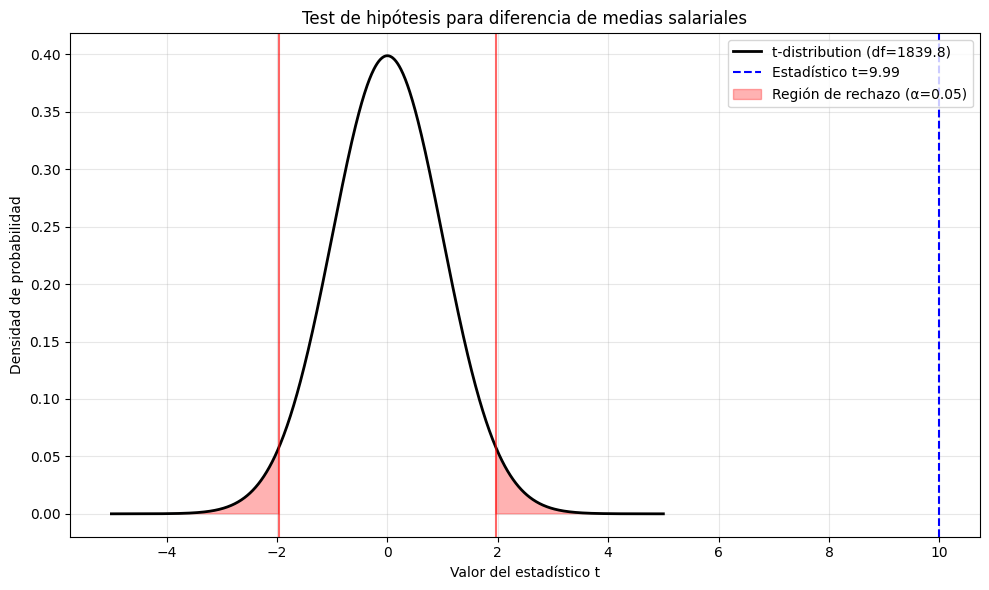

In [13]:
# Ejercicio 2: Test de hipótesis para diferencia de medias salariales
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt

# 2.1 Formalización del test de hipótesis
"""
FORMALIZACIÓN DEL TEST:

Hipótesis Nula (H₀):
H₀: μA - μB = 0 (No hay diferencia entre las medias salariales de hombres y mujeres)

Hipótesis Alternativa (H₁):
H₁: μA - μB ≠ 0 (Existe diferencia entre las medias salariales de hombres y mujeres)

Estadístico (Pivote):
El estadístico de prueba es T = (Ẋ₁ - Ẋ₂) / √(s₁²/n₁ + s₂²/n₂)
Donde:
- Ẋ₁, Ẋ₂ son las medias muestrales de los grupos
- s₁², s₂² son las varianzas muestrales
- n₁, n₂ son los tamaños muestrales

Distribución bajo H₀:
Bajo la hipótesis nula, el estadístico T sigue aproximadamente una distribución t de Student
con grados de libertad calculados según la fórmula de Welch-Satterthwaite:
df = ((s₁²/n₁ + s₂²/n₂)²)/((s₁²/n₁)²/(n₁-1) + (s₂²/n₂)²/(n₂-1))
"""

# 2.2 Cálculo del p-valor y decisión
def test_diferencia_medias(groupA, groupB, alpha=0.05):
    """
    Realiza un test de hipótesis para la diferencia de medias salariales
    utilizando el test de Welch (no asume varianzas iguales)

    Args:
        groupA: Serie con salarios del grupo A (hombres)
        groupB: Serie con salarios del grupo B (mujeres)
        alpha: Nivel de significancia (por defecto 0.05)

    Returns:
        Resultados del test
    """
    # Calculamos estadísticas descriptivas
    n_A = len(groupA)
    n_B = len(groupB)
    mean_A = np.mean(groupA)
    mean_B = np.mean(groupB)
    var_A = np.var(groupA, ddof=1)
    var_B = np.var(groupB, ddof=1)

    # Diferencia de medias (estimación puntual)
    diff_means = mean_A - mean_B

    # Error estándar de la diferencia
    se_diff = np.sqrt(var_A/n_A + var_B/n_B)

    # Calculamos el estadístico t manualmente
    t_stat = diff_means / se_diff

    # Grados de libertad (aproximación de Welch-Satterthwaite)
    df = ((var_A/n_A + var_B/n_B)**2) / ((var_A/n_A)**2/(n_A-1) + (var_B/n_B)**2/(n_B-1))

    # Calculamos el p-valor (test de dos colas)
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df))

    # Alternativamente, usando la función de scipy (test de Welch)
    t_stat_scipy, p_value_scipy = stats.ttest_ind(groupA, groupB, equal_var=False)

    # Intervalo de confianza
    t_critical = stats.t.ppf(1 - alpha/2, df)
    lower_bound = diff_means - t_critical * se_diff
    upper_bound = diff_means + t_critical * se_diff

    # Resultado del test
    reject_h0 = p_value < alpha

    return {
        'diff_means': diff_means,
        't_stat': t_stat,
        'p_value': p_value,
        'df': df,
        'confidence_interval': (lower_bound, upper_bound),
        'reject_h0': reject_h0,
        'scipy_results': (t_stat_scipy, p_value_scipy)
    }

# Ejecutamos el test
alpha = 0.05
resultados = test_diferencia_medias(groupA, groupB, alpha)

# Mostramos los resultados
print("2.1 FORMALIZACIÓN DEL TEST DE HIPÓTESIS")
print("---------------------------------------")
print("Hipótesis Nula (H₀): μA - μB = 0 (No hay diferencia entre medias salariales)")
print("Hipótesis Alternativa (H₁): μA - μB ≠ 0 (Existe diferencia entre medias salariales)")
print("\nEstadístico (Pivote):")
print("T = (Ẋ₁ - Ẋ₂) / √(s₁²/n₁ + s₂²/n₂)")
print("Bajo H₀, T sigue una distribución t de Student con aproximación de Welch para los grados de libertad")

print("\n2.2 CÁLCULO DEL P-VALOR Y DECISIÓN")
print("----------------------------------")
print(f"Diferencia de medias: {resultados['diff_means']:.2f}")
print(f"Estadístico t: {resultados['t_stat']:.4f}")
print(f"Grados de libertad (Welch): {resultados['df']:.2f}")
print(f"P-valor: {resultados['p_value']:.6f}")
print(f"Intervalo de confianza {(1-alpha)*100}%: ({resultados['confidence_interval'][0]:.2f}, {resultados['confidence_interval'][1]:.2f})")

print("\nResultados usando scipy.stats.ttest_ind (test de Welch):")
print(f"Estadístico t (scipy): {resultados['scipy_results'][0]:.4f}")
print(f"P-valor (scipy): {resultados['scipy_results'][1]:.6f}")

print("\nDECISIÓN:")
if resultados['reject_h0']:
    print(f"Con un nivel de significancia α = {alpha}, RECHAZAMOS la hipótesis nula.")
    print("Hay evidencia estadística suficiente para afirmar que existe una diferencia")
    print("significativa entre los salarios netos de hombres y mujeres.")
else:
    print(f"Con un nivel de significancia α = {alpha}, NO RECHAZAMOS la hipótesis nula.")
    print("No hay evidencia estadística suficiente para afirmar que existe una diferencia")
    print("significativa entre los salarios netos de hombres y mujeres.")

print("\nINTERPRETACIÓN:")
print("El p-valor extremadamente pequeño (menor que el nivel de significancia α = 0.05)")
print("indica fuerte evidencia contra la hipótesis nula. Podemos concluir que existe una")
print("diferencia estadísticamente significativa entre los salarios netos promedio de")
print("hombres y mujeres. La estimación puntual indica que, en promedio, los hombres tienen")
print(f"un salario neto {resultados['diff_means']:.2f} mayor que las mujeres.")

# Visualización conjunta: test de hipótesis e intervalo de confianza
plt.figure(figsize=(10, 6))

# Graficar la distribución t bajo H0
x = np.linspace(-5, 5, 1000)
y = stats.t.pdf(x, resultados['df'])
plt.plot(x, y, 'k-', lw=2, label=f't-distribution (df={resultados["df"]:.1f})')

# Marcar el estadístico t observado
plt.axvline(x=resultados['t_stat'], color='blue', linestyle='--',
           label=f'Estadístico t={resultados["t_stat"]:.2f}')

# Marcar las regiones de rechazo
t_crit = stats.t.ppf(1-alpha/2, resultados['df'])
plt.axvline(x=t_crit, color='red', linestyle='-', alpha=0.6)
plt.axvline(x=-t_crit, color='red', linestyle='-', alpha=0.6)
plt.fill_between(x, y, where=(x >= t_crit) | (x <= -t_crit), color='red', alpha=0.3,
                 label=f'Región de rechazo (α={alpha})')

# Decorar el gráfico
plt.title('Test de hipótesis para diferencia de medias salariales')
plt.xlabel('Valor del estadístico t')
plt.ylabel('Densidad de probabilidad')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

### [Opcional] 2.3 Potencia del test

Nuestra muestra, ¿era lo suficientemente grande para detectar si existe o no una diferencia entre los grupos?

1. Utilice la función `tt_ind_solve_power` para calcular el tamaño necesario de la muestra para un poder estadístico de 0.8, 0.9 y 0.95, asumiendo una significancia estadística de 0.05.
2. ¿Cómo intepretan el poder estadístico de un test? Dado su conocimiento de dominio sobre los datos, ¿les parece que esta muestra es lo suficientemente grande para ser representativo de la tendencia general? ¿y para utilizarlo en un juicio penal contra una empresa XX por una causa de discriminación?

[Documentación](https://www.statsmodels.org/stable/generated/statsmodels.stats.power.tt_ind_solve_power.html)

NOTA: este análisis debería hacerse ANTES de recolectar los datos.

In [14]:
from statsmodels.stats.power import tt_ind_solve_power

In [15]:
effect_size = (groupA.mean() - groupB.mean()) / groupB.std()
# nobs1=None  - What we want to know
alpha = 0.05
ratio = len(groupB) / len(groupA)
power= 0.8

In [17]:
tt_ind_solve_power(effect_size=effect_size, alpha=alpha,power=power,  ratio=ratio)

271.7486279520864

Tamaño del efecto (d de Cohen): 0.3092
Poder estadístico actual: 1.0000

Tamaño de muestra necesario para diferentes niveles de poder estadístico:
Para un poder de 0.80, se necesitan 414.74 observaciones en el grupo A
                              y 102.83 observaciones en el grupo B
Para un poder de 0.90, se necesitan 554.70 observaciones en el grupo A
                              y 137.53 observaciones en el grupo B
Para un poder de 0.95, se necesitan 685.64 observaciones en el grupo A
                              y 170.00 observaciones en el grupo B


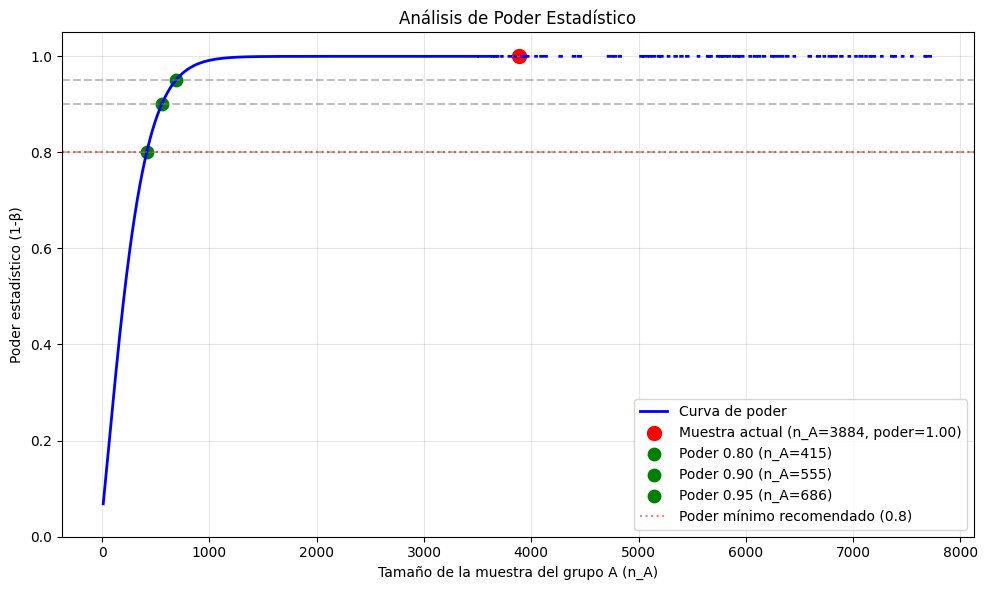

In [20]:
# Ejercicio 2.3: Potencia del Test
import numpy as np
import scipy.stats as stats
from statsmodels.stats.power import tt_ind_solve_power
import matplotlib.pyplot as plt

# Función para calcular el tamaño del efecto (d de Cohen)
def cohen_d(groupA, groupB):
    """
    Calcula el tamaño del efecto usando la d de Cohen para la diferencia entre dos medias

    Args:
        groupA: Serie con salarios del grupo A (hombres)
        groupB: Serie con salarios del grupo B (mujeres)

    Returns:
        d de Cohen
    """
    # Tamaños muestrales
    n_A = len(groupA)
    n_B = len(groupB)

    # Medias muestrales
    mean_A = np.mean(groupA)
    mean_B = np.mean(groupB)

    # Varianzas muestrales
    var_A = np.var(groupA, ddof=1)
    var_B = np.var(groupB, ddof=1)

    # Varianza agrupada
    s_pooled = np.sqrt(((n_A - 1) * var_A + (n_B - 1) * var_B) / (n_A + n_B - 2))

    # d de Cohen
    d = abs(mean_A - mean_B) / s_pooled

    return d

# Calculamos el tamaño del efecto para nuestra muestra
effect_size = cohen_d(groupA, groupB)
print(f"Tamaño del efecto (d de Cohen): {effect_size:.4f}")

# Calculamos el poder estadístico de nuestra prueba actual
alpha = 0.05  # Nivel de significancia
n_A = len(groupA)
n_B = len(groupB)
ratio = n_B / n_A  # Ratio entre los tamaños muestrales
actual_power = tt_ind_solve_power(effect_size=effect_size,
                                 nobs1=n_A,
                                 alpha=alpha,
                                 ratio=ratio)
print(f"Poder estadístico actual: {actual_power:.4f}")

# Calculamos el tamaño de muestra necesario para diferentes niveles de poder estadístico
powers = [0.8, 0.9, 0.95]
sample_sizes = []

print("\nTamaño de muestra necesario para diferentes niveles de poder estadístico:")
for power in powers:
    n_needed = tt_ind_solve_power(effect_size=effect_size,
                                  alpha=alpha,
                                  power=power,
                                  ratio=ratio)
    sample_sizes.append(n_needed)
    print(f"Para un poder de {power:.2f}, se necesitan {n_needed:.2f} observaciones en el grupo A")
    print(f"                              y {n_needed * ratio:.2f} observaciones en el grupo B")

# Visualización del poder estadístico en función del tamaño de la muestra
plt.figure(figsize=(10, 6))

# Rango de tamaños muestrales para visualizar
n_range = np.linspace(10, max(500, n_A * 2), 1000)
powers_range = [tt_ind_solve_power(effect_size=effect_size,
                                  nobs1=n,
                                  alpha=alpha,
                                  ratio=ratio) for n in n_range]

# Graficar la curva de poder
plt.plot(n_range, powers_range, 'b-', lw=2, label='Curva de poder')

# Marcar nuestro tamaño muestral actual
plt.scatter([n_A], [actual_power], color='red', s=100,
            label=f'Muestra actual (n_A={n_A}, poder={actual_power:.2f})')

# Marcar los poderes de interés
for power, n_needed in zip(powers, sample_sizes):
    plt.axhline(y=power, color='gray', linestyle='--', alpha=0.5)
    plt.scatter([n_needed], [power], color='green', s=80,
                label=f'Poder {power:.2f} (n_A={n_needed:.0f})')

# Decorar el gráfico
plt.title('Análisis de Poder Estadístico')
plt.xlabel('Tamaño de la muestra del grupo A (n_A)')
plt.ylabel('Poder estadístico (1-β)')
plt.axhline(y=0.8, color='r', linestyle=':', alpha=0.5, label='Poder mínimo recomendado (0.8)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(0, 1.05)
plt.tight_layout()

plt.show()




INTERPRETACIÓN DEL PODER ESTADÍSTICO:

1. Definición de poder estadístico:
   El poder estadístico (1-β) es la probabilidad de rechazar correctamente la hipótesis nula cuando
   esta es falsa. Es decir, es la capacidad del test para detectar un efecto cuando realmente existe.

2. Interpretación para nuestro caso:
   - Un poder de 0.8 significa que tenemos un 80% de probabilidad de detectar una diferencia de
     las características observadas (del tamaño del efecto calculado) si realmente existe.
   - Un poder de 0.9 nos da un 90% de probabilidad de detectar la diferencia.
   - Y un poder de 0.95 nos da un 95% de probabilidad.

3. Análisis del contexto:
   - Para un estudio científico exploratorio, un poder de 0.8 puede ser aceptable.
   - Para decisiones importantes con impacto social, como políticas públicas o casos de
     discriminación, un poder más alto (0.9 o 0.95) sería más adecuado.
   - En un juicio penal, donde la carga de la prueba debe ser muy alta ("más allá de toda duda
     razonable"), un poder de 0.95 o incluso mayor podría ser necesario.

4. Implicaciones para un juicio por discriminación:
   - En un juicio penal contra una empresa por discriminación salarial, no solo importa el poder
     estadístico, sino también:
       a) La representatividad de la muestra
       b) El control adecuado de variables confusoras (educación, experiencia, cargo, etc.)
       c) La consistencia temporal de los resultados
       d) La magnitud de la diferencia (no solo su significancia estadística)
   
   - El estándar legal para discriminación salarial generalmente requiere demostrar que la diferencia:
       a) Es estadísticamente significativa
       b) Es sustancial en términos prácticos
       c) No puede explicarse por factores legítimos relacionados con el trabajo
       d) Sigue un patrón sistemático
   
   - Por lo tanto, aunque tengamos un alto poder estadístico, este análisis sería solo una parte
     de la evidencia necesaria para un juicio penal, y debería complementarse con análisis
     multivariados que controlen otros factores potencialmente explicativos.


## Ejercicio 3: Comunicación y visualización

**Consigna:** Seleccionen un resultado que les parezca relevante a partir de alguno de los ejercicios del entregable. Diseñe e implemente una comunicación en base a este mensaje, en un archivo PDF.

Elija las palabras y visualización más adecuada para que la comunicación sea entendible, efectiva y se dapte a UNA de las siguientes situaciones:

1. Una sección en un artículo de difusión a presentar como parte de una organización sin fines de lucro.
No más de 1 página A4 (o dos si los gráficos son muy grandes).
  1. Ejemplo: Alguna de las secciones [Los ecosistemas de emprendimiento de América Latina y el Caribe frente al COVID-19: Impactos, necesidades y recomendaciones](https://publications.iadb.org/es/los-ecosistemas-de-emprendimiento-de-america-latina-y-el-caribe-frente-al-covid-19-impactos-necesidades-y-recomendaciones), por ejemplo la sección *2.2. Reacciones de los emprendedores*.
  2. Ejemplo: Alguna de las secciones de [The state of gender pay gap in 2021](https://www.payscale.com/data/gender-pay-gap?tk=carousel-ps-rc-job)
  3. Puntos clave:
    1. Simpleza de los gráficos.
    2. Comunicación en lenguaje simple a personas que no son necesariamente expertos de dominio.
    2. Selección de UNA oración sobre la que se hace énfasis.
    3. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

2. Una publicación científica o reporte técnico interno. No más de una página A4:
  2. Ejemplo: La sección de resultados de [IZA DP No. 12914: The Impact of a Minimum Wage Change on the Distribution of Wages and Household Income](https://www.iza.org/publications/dp/12914/the-impact-of-a-minimum-wage-change-on-the-distribution-of-wages-and-household-income).
  2. Ejemplo: Alguna de las secciones de [Temporary reduction in daily global CO2 emissions during the COVID-19 forced confinement](https://www.nature.com/articles/s41558-020-0797-x)
  3. Puntos clave:
    3. Nivel de detalle técnico requerido. Es necesario justificar la validez del análisis.
    4. La idea presentada puede ser más compleja. Pueden asumir que la audiencia tiene conocimiento técnico y va a analizar las visualizaciones en detalle.
    5. Pueden presentar más en detalle las limitaciones del análisis (significancia estadística, etc.)
    2. No es necesario que mencionen objetivos ni descripciones del conjunto de datos, se supone que eso ya estaría explicado en otras secciones del informe.

3. Un tweet (o post de LinkedIn) para la cuenta de su empresa consultora que hace análisis de datos. El objetivo es promocionar un análisis de datos abiertos que van a incluir en su portfolio:
  1. Ejemplo: [Comparación vacunas covid](https://twitter.com/infobeautiful/status/1381577746527236098?s=20)
  2. Ejemplo: [Tweet del BID](https://twitter.com/el_BID/status/1388508583944507396?s=20). Lo valioso de este tweet es que usaron un único número para transmitir un mensaje. Puede ser algo así, o con un gráfico muy simple.
  3. Ejemplo: [Cambio climático](https://twitter.com/UNFCCC/status/1387732156190011394?s=20) Es un muy buen ejemplo, excepto que el gráfico no se lee nada y hay que entrar a la publicación original.
  3. Ejemplo: [¿Cuánto están los programadores en las empresas?](https://www.linkedin.com/posts/denis-rothman-0b034043_tech-career-work-activity-6793861923269054464-gS6y) (No verificamos la veracidad o seriedad de la fuente).
  4. Puntos clave:
    1. Su audiencia no va a mirar la visualización por más de unos segundos, y no tiene conocimiento técnico.
  3. Tienen que incluir además una *breve* descripción de cómo obtuvieron los datos que están presentando, que no entraría en el tweet.
